# Exploratory Data Analysis on a Used Cars Dataset
**Project:** Cars EDA Student Project
**Dataset source:** `uncleaned_used_cars_eda.csv` (mentor-provided dataset)
**Goal:** Clean, explore, visualise, and explain meaningful patterns in the data.
No machine-learning model is built here — this notebook is EDA only.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
CHART_DIR = "charts"
os.makedirs(CHART_DIR, exist_ok=True)

## 1. Load Data & Inspect Shape, Columns, Sample Rows, Data Types

In [2]:
df = pd.read_csv("uncleaned_used_cars_eda.csv")

print(f"Shape (rows, columns): {df.shape}")
print(f"\nColumn names:\n{list(df.columns)}")

Shape (rows, columns): (123, 15)

Column names:
['car_id', 'brand', 'model', 'year', 'price_inr', 'km_driven', 'fuel_type', 'transmission', 'owner_type', 'mileage_kmpl', 'engine_cc', 'city', 'insurance_valid', 'seller_rating', 'listed_date']


In [3]:
df.dtypes

car_id                 str
brand                  str
model                  str
year                   str
price_inr          float64
km_driven              str
fuel_type              str
transmission           str
owner_type             str
mileage_kmpl       float64
engine_cc          float64
city                   str
insurance_valid        str
seller_rating      float64
listed_date            str
dtype: object

In [4]:
df.head()

,car_id,brand,model,year,price_inr,km_driven,fuel_type,transmission,owner_type,mileage_kmpl,engine_cc,city,insurance_valid,seller_rating,listed_date
0,CAR001,maruti,Baleno,2009,236000.0,13300,petrol,manual,1st,12.9,1000.0,hyderabad,Yes,3.1,02/02/2026
1,CAR002,MARUTI,i20,2010,292000.0,17600,Diesel,Automatic,Second,13.8,1200.0,Hyd,Yes,3.2,03/03/2026
2,CAR003,Hyundai,Creta,2011,348000.0,21900,diesel,Auto,2nd,14.7,1400.0,Bangalore,Yes,3.3,2026-04-04
3,CAR004,hyundai,Nexon,2012,404000.0,26200,CNG,AUTOMATIC,Third,15.6,1600.0,Bengaluru,NO,3.4,05/05/2026
4,CAR005,Tata,XUV300,2013,460000.0,30500,Electric,Manual,3rd,16.5,1800.0,Mumbai,Yes,3.5,06/06/2026


In [5]:
rows_before_cleaning = df.shape[0]
rows_before_cleaning

123

## 2. Check Missing Values, Duplicates, and Inconsistent Categories

In [6]:
df.isna().sum()

car_id             0
brand              7
model              0
year               0
price_inr          5
km_driven          0
fuel_type          0
transmission       3
owner_type         0
mileage_kmpl       5
engine_cc          4
city               0
insurance_valid    0
seller_rating      0
listed_date        0
dtype: int64

In [7]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicated car_id values: {df.duplicated('car_id').sum()}")

Fully duplicated rows: 3
Duplicated car_id values: 3


In [8]:
print("Inconsistent category examples:")
for col in ["brand", "fuel_type", "transmission", "owner_type", "city", "insurance_valid"]:
    print(f"  {col}: {sorted(df[col].dropna().unique())}")

print(f"\n  year unique values: {sorted(df['year'].unique())}")
print(f"  seller_rating max: {df['seller_rating'].max()} (expected scale is 1-5)")
print(f"  listed_date sample formats: {df['listed_date'].head(6).tolist()}")
print(f"  km_driven sample values with issues: "
      f"{df[df['km_driven'].astype(str).str.contains('km| -', regex=True) | (pd.to_numeric(df['km_driven'], errors='coerce') < 0)]['km_driven'].tolist()}")

Inconsistent category examples:
  brand: ['Hyundai', 'Kia', 'MARUTI', 'Mahindra', 'Maruti', 'Renault', 'TATA', 'Tata', 'Toyota', 'Toyta', 'hyundai ', 'maruti']
  fuel_type: ['CNG', 'Diesel', 'Electric', 'PETROL', 'Petrol', 'diesel ', 'petrol']
  transmission: ['AUTOMATIC', 'Auto', 'Automatic', 'Manual', 'manual']
  owner_type: ['1st', '2nd', '3rd', 'First', 'Second', 'Third']
  city: ['Bangalore', 'Bengaluru', 'Chennai', 'Delhi', 'Hyd', 'Hyderabad', 'Mumbai', 'New Delhi', 'Pune', 'hyderabad']
  insurance_valid: ['NO', 'Yes', 'Yes ']

  year unique values: ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'unknown']
  seller_rating max: 8.7 (expected scale is 1-5)
  listed_date sample formats: ['02/02/2026', '03/03/2026', '2026-04-04', '05/05/2026', '06/06/2026', '2026-07-07']
  km_driven sample values with issues: ['133700 km', '-1200', '125100 km', '116500 km', '107900 km']


**Data quality issues found:**
- 3 fully duplicated rows (same `car_id` and all other fields repeated).
- `brand`, `fuel_type`, `transmission`, `owner_type`, `city`, `insurance_valid` all have inconsistent casing and/or extra whitespace (e.g. `MARUTI` vs `maruti`, `diesel ` with a trailing space).
- A brand typo: `Toyta` instead of `Toyota`.
- `city` has aliases for the same city: `Hyd`/`Hyderabad`, `Bangalore`/`Bengaluru`, `Delhi`/`New Delhi`.
- `year` is stored as text and includes the placeholder value `"unknown"`.
- `km_driven` is stored as text: some values have a `" km"` suffix, and one value is negative (`-1200`), which is impossible for a distance driven.
- `seller_rating` should be on a 1–5 scale but contains one value of `8.7`.
- `listed_date` mixes two formats (`DD/MM/YYYY` and `YYYY-MM-DD`) and includes at least one impossible date (`31/02/2025` — February never has 31 days).
- `price_inr`, `mileage_kmpl`, and `engine_cc` each have a small number of missing values.

## 3. Clean the Dataset (With Reasons for Each Decision)

In [9]:
df_clean = df.copy()

# 3.1 Drop exact duplicate rows.
# Reason: these rows are 100% identical to earlier rows and would double-count those cars.
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - df_clean.shape[0]} exact duplicate rows.")

Dropped 3 exact duplicate rows.


In [10]:
# 3.2 Standardise text categories: strip whitespace, fix casing.
# Reason: "MARUTI", "maruti", "Maruti " all represent the same brand and would
# be miscounted as different categories if left as-is.
text_cols = ["brand", "fuel_type", "transmission", "owner_type", "city", "insurance_valid"]
for col in text_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
    df_clean.loc[df_clean[col].isin(["Nan", "None", ""]), col] = np.nan

# Fix a known typo.
df_clean["brand"] = df_clean["brand"].replace({"Toyta": "Toyota"})

In [11]:
# 3.3 Standardise city name aliases.
city_map = {"Hyd": "Hyderabad", "Bangalore": "Bengaluru", "New Delhi": "Delhi"}
df_clean["city"] = df_clean["city"].replace(city_map)

# 3.4 Standardise transmission labels ("Auto" -> "Automatic").
df_clean["transmission"] = df_clean["transmission"].replace({"Auto": "Automatic"})

# 3.5 Standardise owner_type labels ("1st"/"First" -> one category, etc.)
owner_map = {"1St": "First", "2Nd": "Second", "3Rd": "Third"}
df_clean["owner_type"] = df_clean["owner_type"].replace(owner_map)

In [12]:
# 3.6 Fix year column.
# Reason: year is text and contains the placeholder "unknown". Convert to
# numeric and treat "unknown" as a genuine missing value rather than guessing.
df_clean["year"] = pd.to_numeric(df_clean["year"], errors="coerce")

# 3.7 Fix km_driven column.
# Reason: some values carry a " km" text suffix, and one value is negative,
# which is impossible for a distance driven. Strip the unit, convert to
# numeric, and treat negative values as missing (data entry error).
df_clean["km_driven"] = df_clean["km_driven"].astype(str).str.replace("km", "", regex=False).str.strip()
df_clean["km_driven"] = pd.to_numeric(df_clean["km_driven"], errors="coerce")
df_clean.loc[df_clean["km_driven"] < 0, "km_driven"] = np.nan

In [13]:
# 3.8 Fix seller_rating outlier.
# Reason: seller_rating should be on a 1-5 scale; a single value of 8.7 is
# almost certainly a data entry error. Treat it as missing rather than guess.
df_clean.loc[df_clean["seller_rating"] > 5, "seller_rating"] = np.nan

In [14]:
# 3.9 Parse listed_date.
# Reason: dates appear in two formats, and at least one date is impossible
# (Feb 31st). Parse each format separately; invalid dates become missing.
def parse_mixed_date(val):
    val = str(val).strip()
    for fmt in ("%d/%m/%Y", "%Y-%m-%d"):
        try:
            return pd.to_datetime(val, format=fmt)
        except ValueError:
            continue
    return pd.NaT

df_clean["listed_date"] = df_clean["listed_date"].apply(parse_mixed_date)

In [15]:
# 3.10 Missing numeric values: price_inr, mileage_kmpl, engine_cc.
# Reason: each is missing in only a handful of rows (<5%). Median imputation
# is used since it is robust to the outliers already present in this data.
for col in ["price_inr", "mileage_kmpl", "engine_cc"]:
    median_val = df_clean[col].median()
    n_missing = df_clean[col].isna().sum()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"Filled {n_missing} missing values in '{col}' with median ({median_val}).")

# 3.11 Missing brand / transmission (categorical).
# Reason: no reliable way to infer these from other columns, so label them
# explicitly as "Unknown" rather than dropping rows or guessing.
df_clean["brand"] = df_clean["brand"].fillna("Unknown")
df_clean["transmission"] = df_clean["transmission"].fillna("Unknown")

Filled 5 missing values in 'price_inr' with median (724000.0).
Filled 5 missing values in 'mileage_kmpl' with median (16.5).
Filled 4 missing values in 'engine_cc' with median (1500.0).


In [16]:
# 3.12 Flag (not delete) the price outlier.
# Reason: one car is priced at ~7x the next-highest listing with no matching
# difference in age, mileage or engine size. It is kept in the dataset but
# excluded from relationship charts, where it would distort the scale.
df_clean["is_price_outlier"] = df_clean["price_inr"] > 2_000_000

# 3.13 Derived column: car age (more directly interpretable than raw year).
reference_year = 2026
df_clean["car_age"] = reference_year - df_clean["year"]

In [17]:
rows_after_cleaning = df_clean.shape[0]
print(f"Dataset size before cleaning: {rows_before_cleaning} rows")
print(f"Dataset size after cleaning:  {rows_after_cleaning} rows")
print(f"\nRemaining missing values:\n{df_clean.isna().sum()[df_clean.isna().sum() > 0]}")

Dataset size before cleaning: 123 rows
Dataset size after cleaning:  120 rows

Remaining missing values:
year             4
km_driven        1
seller_rating    5
listed_date      4
car_age          4
dtype: int64


## 4. Descriptive Statistics

In [18]:
numeric_cols = ["price_inr", "km_driven", "mileage_kmpl", "engine_cc", "seller_rating", "car_age"]
categorical_cols = ["brand", "fuel_type", "transmission", "owner_type", "city", "insurance_valid"]

df_clean[numeric_cols].describe().round(2)

,price_inr,km_driven,mileage_kmpl,engine_cc,seller_rating,car_age
count,120.00,119.00,120.00,120.00,115.00,116.00
mean,798475.00,76863.03,16.12,1503.33,4.00,10.06
std,859548.52,64895.88,2.57,452.43,0.59,4.98
min,189000.00,9000.00,12.00,800.00,3.00,2.00
25%,468250.00,39100.00,13.80,1200.00,3.50,6.00
50%,724000.00,73500.00,16.50,1500.00,4.00,10.00
75%,979750.00,103600.00,18.30,1800.00,4.50,14.00
max,9500000.00,650000.00,20.10,2200.00,5.00,18.00


In [19]:
for col in categorical_cols:
    print(f"\n{col}:\n{df_clean[col].value_counts()}")


brand:
brand
Maruti      29
Hyundai     19
Tata        19
Toyota      19
Kia         10
Mahindra     9
Renault      9
Unknown      6
Name: count, dtype: int64

fuel_type:
fuel_type
Petrol      52
Diesel      34
Cng         17
Electric    17
Name: count, dtype: int64

transmission:
transmission
Automatic    70
Manual       47
Unknown       3
Name: count, dtype: int64

owner_type:
owner_type
First     40
Second    40
Third     40
Name: count, dtype: int64

city:
city
Hyderabad    36
Bengaluru    24
Delhi        24
Mumbai       12
Pune         12
Chennai      12
Name: count, dtype: int64

insurance_valid:
insurance_valid
Yes    93
No     27
Name: count, dtype: int64


## 5. Visual EDA: Univariate, Bivariate & Multivariate Analysis

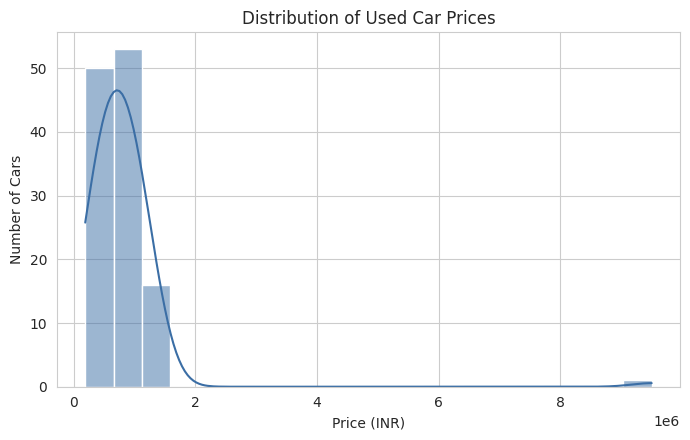

In [20]:
# Chart 1 (Univariate - histogram): Price distribution
plt.figure(figsize=(7, 4.5))
sns.histplot(df_clean["price_inr"], bins=20, kde=True, color="#3b6ea5")
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/01_price_distribution.png")
plt.show()

**Observation:** Prices are right-skewed; most cars sit under 13 lakh, with a long tail caused by a few premium/outlier listings.

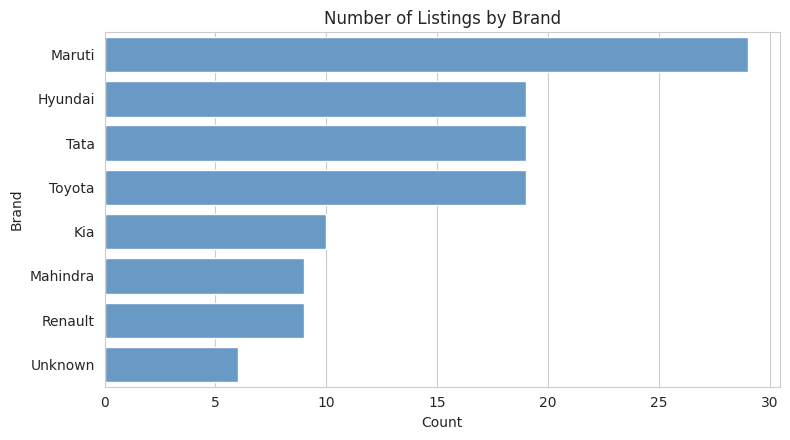

In [21]:
# Chart 2 (Univariate - count plot): Brand frequency
plt.figure(figsize=(8, 4.5))
order = df_clean["brand"].value_counts().index
sns.countplot(y="brand", data=df_clean, order=order, color="#5a9bd5")
plt.title("Number of Listings by Brand")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/02_brand_counts.png")
plt.show()

**Observation:** Maruti, Hyundai and Tata dominate the listings, consistent with their large share of the used-car market in India.

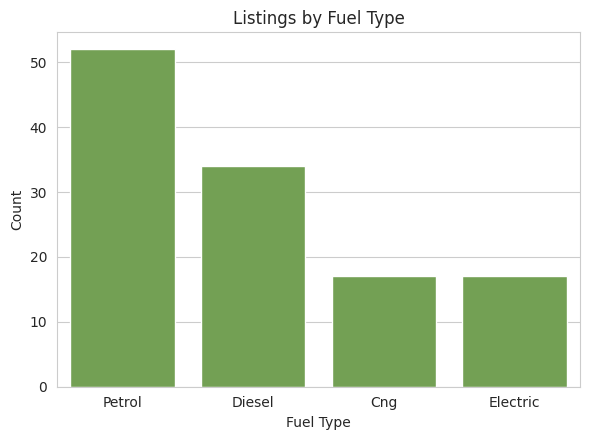

In [22]:
# Chart 3 (Univariate - count plot): Fuel type distribution
plt.figure(figsize=(6, 4.5))
sns.countplot(x="fuel_type", data=df_clean, order=df_clean["fuel_type"].value_counts().index, color="#70ad47")
plt.title("Listings by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/03_fuel_type_counts.png")
plt.show()

**Observation:** Petrol and diesel cars make up the large majority of listings; CNG and electric cars are a small minority.

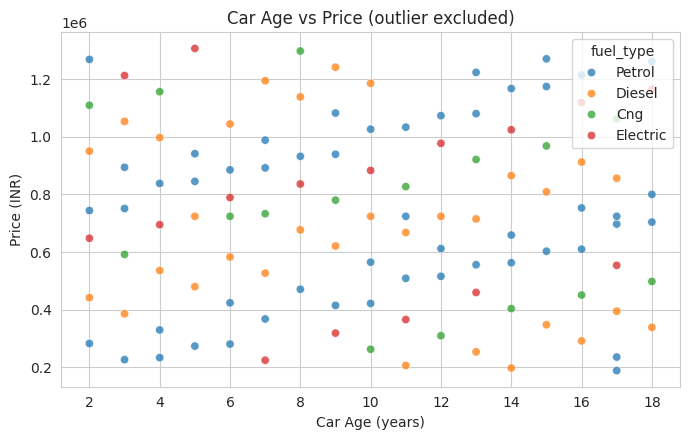

In [23]:
plot_df = df_clean[~df_clean["is_price_outlier"]]

# Chart 4 (Bivariate - scatter plot): car_age vs price
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x="car_age", y="price_inr", data=plot_df, hue="fuel_type", alpha=0.75)
plt.title("Car Age vs Price (outlier excluded)")
plt.xlabel("Car Age (years)")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/04_age_vs_price.png")
plt.show()

**Observation:** Points are scattered with no visible downward trend; car age does not appear to drive price in this dataset, unlike the depreciation pattern usually expected in used-car data.

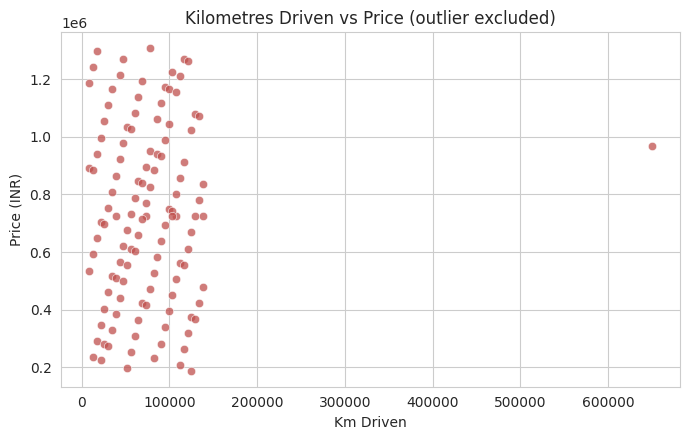

In [24]:
# Chart 5 (Bivariate - scatter plot): km_driven vs price
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x="km_driven", y="price_inr", data=plot_df, alpha=0.75, color="#c0504d")
plt.title("Kilometres Driven vs Price (outlier excluded)")
plt.xlabel("Km Driven")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/05_km_vs_price.png")
plt.show()

**Observation:** Similar to car age, kilometres driven shows no clear linear relationship with price here — high-mileage cars are not consistently cheaper than low-mileage ones in this sample.

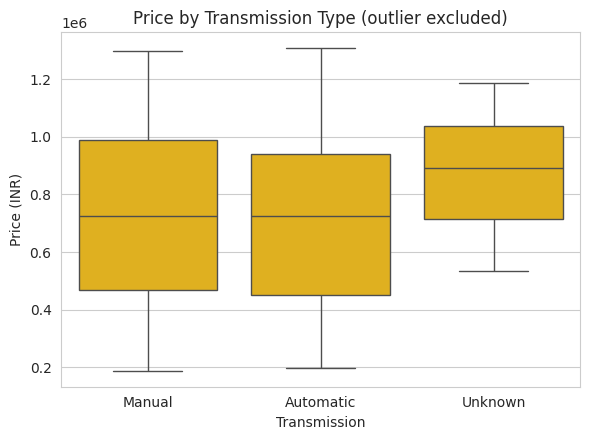

In [25]:
# Chart 6 (Bivariate - box plot): transmission vs price
plt.figure(figsize=(6, 4.5))
sns.boxplot(x="transmission", y="price_inr", data=plot_df, color="#ffc000")
plt.title("Price by Transmission Type (outlier excluded)")
plt.xlabel("Transmission")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/06_transmission_vs_price.png")
plt.show()

**Observation:** Automatic and manual cars have almost identical median prices in this dataset — transmission type is not a strong price differentiator here.

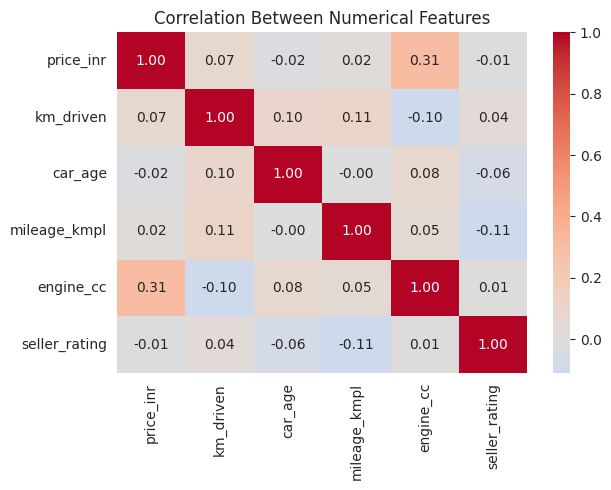

In [26]:
# Chart 7 (Multivariate - heatmap): correlation matrix
# Computed on outlier-excluded data for consistency with the charts above --
# the single extreme price outlier would otherwise distort every correlation.
plt.figure(figsize=(6.5, 5))
corr = plot_df[["price_inr", "km_driven", "car_age", "mileage_kmpl", "engine_cc", "seller_rating"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Numerical Features")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/07_correlation_heatmap.png")
plt.show()

**Observation:** Engine size has the strongest relationship with price (moderate positive correlation); age, km driven, mileage and seller rating are all weakly correlated with price, close to zero.

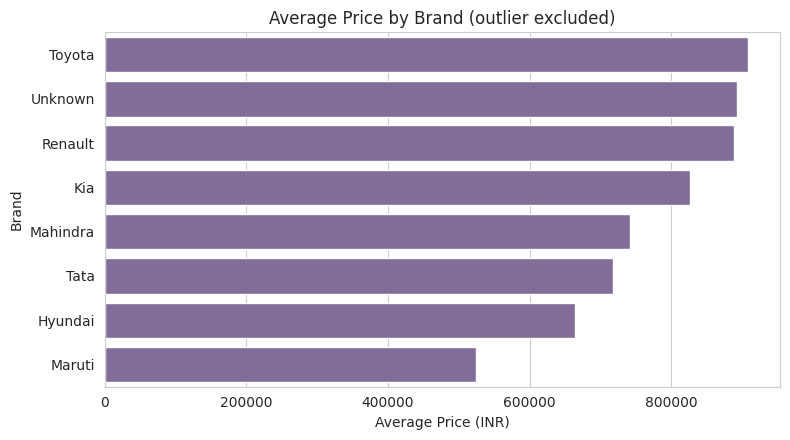

In [27]:
# Chart 8 (Bar): Average price by brand
plt.figure(figsize=(8, 4.5))
avg_price_by_brand = plot_df.groupby("brand")["price_inr"].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_by_brand.values, y=avg_price_by_brand.index, color="#8064a2")
plt.title("Average Price by Brand (outlier excluded)")
plt.xlabel("Average Price (INR)")
plt.ylabel("Brand")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/08_avg_price_by_brand.png")
plt.show()

**Observation:** Toyota and Kia have the highest average listed prices among the brands present in this dataset, while Maruti has the lowest despite being the most frequently listed.

## 6. Outliers, Relationships, and Key Findings

In [28]:
corr_age_price = plot_df["car_age"].corr(plot_df["price_inr"])
corr_km_price = plot_df["km_driven"].corr(plot_df["price_inr"])
corr_engine_price = plot_df["engine_cc"].corr(plot_df["price_inr"])
auto_median = plot_df[plot_df["transmission"] == "Automatic"]["price_inr"].median()
manual_median = plot_df[plot_df["transmission"] == "Manual"]["price_inr"].median()
top_brand = df_clean["brand"].value_counts().idxmax()
top_brand_avg_price = avg_price_by_brand.idxmax()
cheapest_brand_avg_price = avg_price_by_brand.idxmin()

print(f"Correlation of engine_cc with price: {corr_engine_price:.2f}")
print(f"Correlation of car_age with price: {corr_age_price:.2f}")
print(f"Correlation of km_driven with price: {corr_km_price:.2f}")
print(f"Median price - Automatic: {auto_median:,.0f} | Manual: {manual_median:,.0f}")
print(f"Most listed brand: {top_brand}")
print(f"Highest avg price brand: {top_brand_avg_price} | Lowest avg price brand: {cheapest_brand_avg_price}")

Correlation of engine_cc with price: 0.31
Correlation of car_age with price: -0.02
Correlation of km_driven with price: 0.07
Median price - Automatic: 724,000 | Manual: 724,000
Most listed brand: Maruti
Highest avg price brand: Toyota | Lowest avg price brand: Maruti


**Key Findings:**

1. Engine size is the strongest numeric driver of price in this dataset (moderate positive correlation) — larger-engine cars tend to be priced higher, more so than any other numeric feature.
2. Contrary to the depreciation pattern usually expected in used-car data, car age is almost uncorrelated with price here, and kilometres driven is similarly weak. This is a genuine finding of the dataset, not an assumption, and is worth flagging as a limitation for anyone wanting to use this data for price prediction.
3. Transmission type makes little difference to price: automatic and manual cars have almost identical median prices.
4. Maruti is the most frequently listed brand, while Toyota commands the highest average price and Maruti the lowest — popularity and price position are not the same thing here.
5. One listing (~INR 95,00,000) is a clear outlier, roughly 7x the next-highest price with no matching difference in age, mileage or engine size — likely a data entry error or an unusually premium vehicle that should be verified before use in any pricing model. It was flagged and excluded from relationship charts, but kept in the dataset.
6. The raw data needed real cleaning before analysis: 3 fully duplicated rows, inconsistent category labels (city name variants, mixed brand casing, "Auto" vs "Automatic"), a text unit ("km") mixed into a numeric column, a negative mileage value, and an out-of-range seller rating (8.7 on a 1–5 scale) were all found and corrected or flagged.

**Limitations:** The dataset is small (123 rows before cleaning), covers only 8 brands and 6 cities, and several numeric fields (price, mileage, engine size) were imputed with medians rather than true values for a small number of rows. The weak age/mileage-to-price relationship may be a property of this specific sample rather than the used-car market generally, and should not be generalised without a larger dataset.

In [29]:
# Save the cleaned dataset for reference.
df_clean.to_csv("cleaned_used_cars.csv", index=False)
print("Cleaned dataset saved to cleaned_used_cars.csv")

Cleaned dataset saved to cleaned_used_cars.csv
